In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df=pd.read_csv('SOCR-HeightWeight.csv')
df=df.drop('Index',axis=1)
df=df.head(2500)
df['Height(Inches)']=df.pop('Height(Inches)')

In [78]:
df

,Weight(Pounds),Height(Inches)
0,112.9925,65.78331
1,136.4873,71.51521
2,153.0269,69.39874
3,142.3354,68.21660
4,144.2971,67.78781
...,...,...
2495,122.7189,68.31433
2496,125.6964,68.63014
2497,126.2062,68.12174
2498,155.2615,67.40773


In [79]:
df.corr()

,Weight(Pounds),Height(Inches)
Weight(Pounds),1.000000,0.505138
Height(Inches),0.505138,1.000000


In [80]:
df.shape

(2500, 2)

<Axes: xlabel='Weight(Pounds)', ylabel='Height(Inches)'>

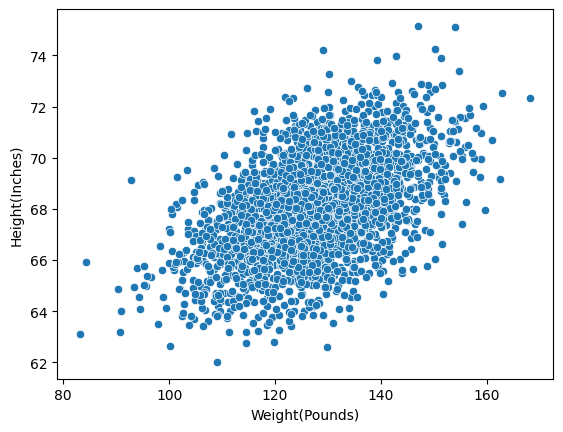

In [81]:
sns.scatterplot(x='Weight(Pounds)',y='Height(Inches)',data=df)

In [82]:
df.corr()

,Weight(Pounds),Height(Inches)
Weight(Pounds),1.000000,0.505138
Height(Inches),0.505138,1.000000


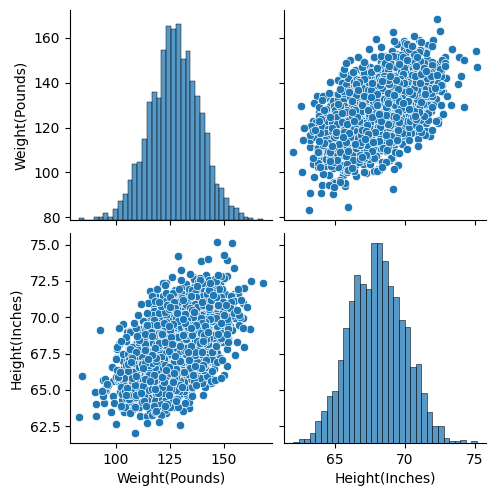

In [83]:
sns.pairplot(df)

In [84]:
# Independent feature
X=df[['Weight(Pounds)']] 
X.shape


(2500, 1)

In [85]:
# Dependent Feature
y=df['Height(Inches)']
np.array(y).shape

(2500,)

In [86]:
##splitting the train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [87]:
#Standardization
from sklearn.preprocessing import StandardScaler
scalaar=StandardScaler()
X_train=scalaar.fit_transform(X_train)
X_train

array([[ 0.30319778],
       [-1.30908492],
       [ 1.07378753],
       ...,
       [-1.36128166],
       [-1.65510421],
       [-0.55062203]])

In [88]:
X_test=scalaar.transform(X_test)
X_test

array([[ 0.22240699],
       [ 2.08629826],
       [-0.74051119],
       [ 1.1384844 ],
       [-1.13423064],
       [ 0.65091847],
       [-0.4735726 ],
       [ 0.70700414],
       [-0.43305134],
       [ 1.54461717],
       [ 0.4378867 ],
       [ 0.64814067],
       [-2.37851205],
       [ 1.12794609],
       [-0.81269946],
       [-0.18270147],
       [-1.59308099],
       [-0.18595671],
       [ 0.86757875],
       [-0.55784433],
       [ 0.19249348],
       [-1.04870022],
       [ 0.44926703],
       [-1.58910525],
       [-1.00198098],
       [ 0.2115041 ],
       [ 0.3657592 ],
       [ 0.10067827],
       [-2.09437102],
       [-0.34873621],
       [ 1.46420834],
       [ 1.58555511],
       [ 0.6465087 ],
       [-0.73512051],
       [ 1.45153459],
       [ 1.51619673],
       [-0.07543471],
       [-0.82864581],
       [ 1.34116884],
       [-0.95744057],
       [ 0.81967026],
       [-0.07322982],
       [-0.30821495],
       [ 0.67788056],
       [-0.02138031],
       [-1

In [89]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [90]:
print("The slope of the best fit line is {}".format(regression.coef_))
print("The intercept of the best line {}".format(regression.intercept_))

The slope of the best fit line is [0.97936812]
The intercept of the best line 68.01698818133333


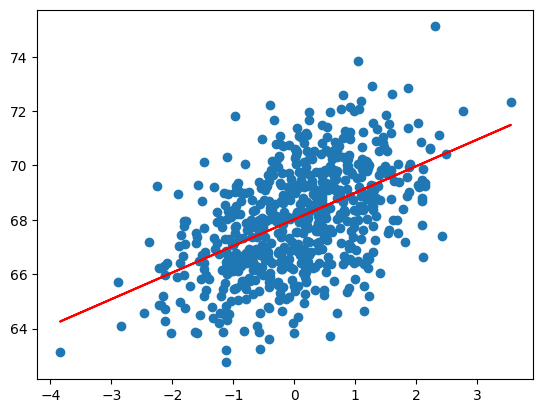

In [91]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),'r')

## Prediction on test data
#### predicted height output = coef_*(weights)+intercepts
#### y_pred_test = 1.13(weights)+68.57

In [92]:
#prediction on test data
print(X_test)
y_pred=regression.predict(X_test)
print(y_pred)

[[ 0.22240699]
 [ 2.08629826]
 [-0.74051119]
 [ 1.1384844 ]
 [-1.13423064]
 [ 0.65091847]
 [-0.4735726 ]
 [ 0.70700414]
 [-0.43305134]
 [ 1.54461717]
 [ 0.4378867 ]
 [ 0.64814067]
 [-2.37851205]
 [ 1.12794609]
 [-0.81269946]
 [-0.18270147]
 [-1.59308099]
 [-0.18595671]
 [ 0.86757875]
 [-0.55784433]
 [ 0.19249348]
 [-1.04870022]
 [ 0.44926703]
 [-1.58910525]
 [-1.00198098]
 [ 0.2115041 ]
 [ 0.3657592 ]
 [ 0.10067827]
 [-2.09437102]
 [-0.34873621]
 [ 1.46420834]
 [ 1.58555511]
 [ 0.6465087 ]
 [-0.73512051]
 [ 1.45153459]
 [ 1.51619673]
 [-0.07543471]
 [-0.82864581]
 [ 1.34116884]
 [-0.95744057]
 [ 0.81967026]
 [-0.07322982]
 [-0.30821495]
 [ 0.67788056]
 [-0.02138031]
 [-1.56023342]
 [ 1.04849213]
 [ 0.07106858]
 [ 0.1812694 ]
 [-0.05075562]
 [-1.61253432]
 [ 0.551282  ]
 [ 1.05564498]
 [-1.31795654]
 [ 2.4804691 ]
 [-0.89649375]
 [-0.67649142]
 [-0.50726219]
 [ 2.10666306]
 [ 2.13550885]
 [ 1.04074899]
 [-1.80174639]
 [ 0.16142544]
 [-1.22187046]
 [-0.50609031]
 [ 0.15164235]
 [-1.32587

## Evaluation


In [95]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_pred,y_test)
mae=mean_absolute_error(y_pred,y_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.9180351003859064
1.3739695108444077
1.7082257170485131


##### R squared 

In [68]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.2555161761394964

In [69]:
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))
adjusted_r2

0.25432117802736076

In [70]:
#New data point weight is 80

weight=np.array([80])
scaled_weight=scalaar.transform([weight])
scaled_weight

/Users/barunwason/python/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-4.10802949]])

In [71]:
predict_height=regression.predict(scaled_weight)
predict_height

array([63.99371505])

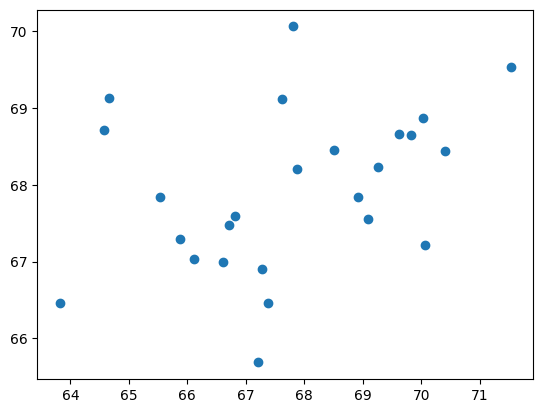

In [73]:
plt.scatter(y_test[:25],y_pred[:25])

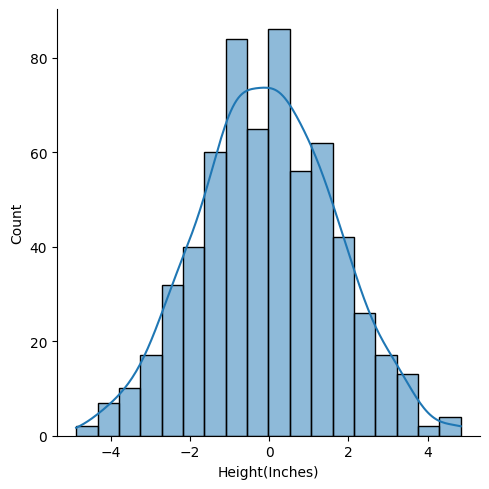

In [75]:
residual=y_test-y_pred
sns.displot(residual,kde=True)